<a href="https://colab.research.google.com/github/stella1298/AIFFEL_Quest_EPA/blob/master/NLP/NLP02/260904_haena_pjt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# ============================================================
# 프로젝트 : 모든 장르 간 편향성 측정
# ============================================================

# 필요한 라이브러리 설치
!pip install konlpy -q
!pip install gensim -q


# ------------------------------------------------------------
# 라이브러리 버전 확인
# ------------------------------------------------------------

import konlpy
import gensim
import sklearn
import seaborn

print("konlpy :", konlpy.__version__)
print("gensim :", gensim.__version__)
print("sklearn:", sklearn.__version__)
print("seaborn:", seaborn.__version__)

konlpy : 0.6.0
gensim : 4.4.0
sklearn: 1.6.1
seaborn: 0.13.2


In [10]:
# ============================================================
# 데이터 경로
# ============================================================
data_dir = "/content/drive/MyDrive/Aiffel_EPA/weat/data/"


# 예술영화 / 일반영화
art_txt = 'synopsis_art.txt'
gen_txt = 'synopsis_gen.txt'


# ------------------------------------------------------------
# 전체 영화 장르 파일
# ------------------------------------------------------------
genre_txt = ['synopsis_SF.txt', 'synopsis_family.txt', 'synopsis_show.txt', 'synopsis_horror.txt', 'synopsis_etc.txt',
             'synopsis_documentary.txt', 'synopsis_drama.txt', 'synopsis_romance.txt', 'synopsis_musical.txt',
             'synopsis_mystery.txt', 'synopsis_crime.txt', 'synopsis_historical.txt', 'synopsis_western.txt',
             'synopsis_adult.txt', 'synopsis_thriller.txt', 'synopsis_animation.txt', 'synopsis_action.txt',
             'synopsis_adventure.txt', 'synopsis_war.txt', 'synopsis_comedy.txt', 'synopsis_fantasy.txt']
genre_name = ['SF', '가족', '공연', '공포(호러)', '기타', '다큐멘터리', '드라마', '멜로로맨스', '뮤지컬', '미스터리', '범죄', '사극', '서부극(웨스턴)',
         '성인물(에로)', '스릴러', '애니메이션', '액션', '어드벤처', '전쟁', '코미디', '판타지']

print("장르 수 :", len(genre_txt))

장르 수 : 21


In [13]:
# ============================================================
# STEP 1. 형태소 분석
# ============================================================
from konlpy.tag import Okt
from tqdm.notebook import tqdm

okt = Okt()


def read_token(file_name):

    result = []
    file_path = data_dir + '/' + file_name

    # --------------------------------------------------------
    # 전체 줄 수를 먼저 계산
    # tqdm에서 진행률을 표시하기 위해 사용
    # --------------------------------------------------------

    with open(file_path, 'r', encoding='utf-8') as fread:
        total_lines = sum(1 for line in fread)


    # --------------------------------------------------------
    # 실제 형태소 분석
    # --------------------------------------------------------

    with open(file_path, 'r', encoding='utf-8') as fread:
        print(file_name, '파일을 읽고 형태소 분석을 진행합니다.')

        for line in tqdm(
            fread,
            total=total_lines,
            desc="분석 진행률"
        ):

            tokenlist = okt.pos(
                line,
                stem=True,
                norm=True
            )

            for word in tokenlist:

                # 명사만 추출
                if word[1] in ["Noun"]:

                    # 한 글자 명사는 의미가 불분명한 경우가 많으므로 제외
                    if len(word[0]) >= 2:
                        result.append(word[0])

    # 하나의 문자열로 반환
    return ' '.join(result)

print("슝~")

슝~


In [14]:
# ============================================================
# 예술영화 / 일반영화 형태소 분석
# ============================================================

art = read_token(art_txt)

gen = read_token(gen_txt)

print("예술영화 형태소 분석 완료")
print("일반영화 형태소 분석 완료")

synopsis_art.txt 파일을 읽고 형태소 분석을 진행합니다.


분석 진행률: 100%|██████████| 14435/14435 [00:44<00:00, 322.96it/s]


synopsis_gen.txt 파일을 읽고 형태소 분석을 진행합니다.


분석 진행률: 100%|██████████| 48116/48116 [03:59<00:00, 201.22it/s]


예술영화 형태소 분석 완료
일반영화 형태소 분석 완료


In [15]:
# ============================================================
# 21개 장르 형태소 분석
# ============================================================

genre = []

for file_name in genre_txt:
    genre.append(read_token(file_name))

print("\n전체 장르 형태소 분석 완료")
print("분석한 장르 수 :", len(genre))

synopsis_SF.txt 파일을 읽고 형태소 분석을 진행합니다.


분석 진행률: 100%|██████████| 1023/1023 [00:04<00:00, 239.85it/s]


synopsis_family.txt 파일을 읽고 형태소 분석을 진행합니다.


분석 진행률: 100%|██████████| 422/422 [00:01<00:00, 288.27it/s]


synopsis_show.txt 파일을 읽고 형태소 분석을 진행합니다.


...

synopsis_comedy.txt 파일을 읽고 형태소 분석을 진행합니다.


분석 진행률: 100%|██████████| 4635/4635 [00:28<00:00, 161.52it/s]


synopsis_fantasy.txt 파일을 읽고 형태소 분석을 진행합니다.


분석 진행률: 100%|██████████| 801/801 [00:03<00:00, 253.01it/s]


전체 장르 형태소 분석 완료
분석한 장르 수 : 21


In [43]:
# ============================================================
# STEP 2. Word2Vec Embedding Model 만들기
# ============================================================

from gensim.models import Word2Vec


# ------------------------------------------------------------
# 예술영화 + 일반영화 + 모든 장르를 하나의 학습 데이터로 구성
# ------------------------------------------------------------

all_text = [art, gen] + genre


# Word2Vec은 문장 단위의 단어 리스트를 입력으로 사용하므로
# 각 문서를 단어 리스트로 변환한다.

sentences = []

for text in all_text:

    tokens = text.split()

    if len(tokens) > 1:
        sentences.append(tokens)


print("Word2Vec 학습 문서 수 :", len(sentences))


# ------------------------------------------------------------
# Word2Vec 모델 학습
# ------------------------------------------------------------
#영화 시놉시스는 전문적인 고유명사, 장르별 희귀 단어가 많음.
#min_count가 너무 높이면 중요 단어가 vocabulary에서 빠질 수 있음
model = Word2Vec(sentences=sentences, vector_size=100, window=5, min_count=2, workers=4, sg=1, epochs=20, seed=42)

print("Word2Vec 학습 완료")
print("Vocabulary 크기 :", len(model.wv))

Word2Vec 학습 문서 수 : 23
Word2Vec 학습 완료
Vocabulary 크기 : 41076


In [44]:
# ============================================================
# Word2Vec most_similar() 확인
# ============================================================

test_words = ['사랑','범죄','전쟁','가족','학교']

for word in test_words:
    if word in model.wv:
        print("\n[" + word + "]와 유사한 단어")
        print(model.wv.most_similar(word, topn=10))
    else:
        print("\n[" + word + "]는 Word2Vec vocabulary에 없습니다.")


[사랑]와 유사한 단어
[('연인', 0.6519283652305603), ('포트만', 0.6203799843788147), ('파국', 0.6174392700195312), ('이별', 0.6088477373123169), ('인하', 0.6084498763084412), ('영영', 0.6072169542312622), ('나탈리', 0.6064688563346863), ('연아', 0.6009525656700134), ('하늘빛', 0.600762665271759), ('뒤로', 0.6007445454597473)]

[범죄]와 유사한 단어
[('삼합회', 0.7620859742164612), ('일파', 0.7126532196998596), ('유덕화', 0.7081390619277954), ('기승', 0.7068968415260315), ('신진', 0.7059448957443237), ('절취', 0.7057626843452454), ('강경', 0.7052406668663025), ('라트렐', 0.6999596357345581), ('부패', 0.6983234286308289), ('라임', 0.6965917944908142)]

[전쟁]와 유사한 단어
[('선포', 0.6778430342674255), ('공비', 0.6602485179901123), ('압도', 0.6599483489990234), ('퇴색', 0.6519560813903809), ('향방', 0.6472008228302002), ('전지', 0.6379352807998657), ('야만', 0.6379178166389465), ('역도', 0.6363198161125183), ('사활', 0.6345828175544739), ('플라톤', 0.6330210566520691)]

[가족]와 유사한 단어
[('데코', 0.585393488407135), ('규호', 0.5782607197761536), ('부양', 0.5781062841415405), ('구토', 0.55

In [45]:
# ============================================================
# STEP 3. TF-IDF를 이용한 대표 단어 후보 추출
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np


def get_tfidf_candidates(text, top_n=100):

    # 하나의 장르 문서를 하나의 document로 취급
    vectorizer = TfidfVectorizer()

    X = vectorizer.fit_transform([text])

    # sparse matrix에서 TF-IDF 값 확인
    matrix = X[0].tocoo()

    words = [
        [i, j]
        for i, j in zip(
            matrix.col,
            matrix.data
        )
    ]


    # TF-IDF가 높은 순서대로 정렬
    words.sort(
        key=lambda x: x[1],
        reverse=True
    )


    feature_names = vectorizer.get_feature_names_out()


    # 단어와 TF-IDF 점수를 함께 반환
    result = []

    for i in range(
        min(top_n, len(words))
    ):

        word_index = words[i][0]
        score = words[i][1]

        word = feature_names[word_index]

        result.append(
            (word, score)
        )

    return result

In [46]:
# ============================================================
# TF-IDF 후보 중 의미적으로 중복되는 단어 제거
# ============================================================

def select_representative_words(
    candidates,
    model,
    word_count=8,
    similarity_threshold=0.70
):

    selected = []


    for word, score in candidates:

        # Word2Vec vocabulary에 없는 단어는 제외
        if word not in model.wv:
            continue


        # 이미 선택된 단어와 의미적으로 너무 비슷한지 확인
        is_duplicate = False


        for selected_word in selected:

            similarity = model.wv.similarity(
                word,
                selected_word
            )


            # cosine similarity가 기준 이상이면
            # 이미 선택된 단어와 의미적으로 중복된 것으로 판단
            if similarity >= similarity_threshold:

                is_duplicate = True
                break


        # 중복되지 않은 단어만 선택
        if not is_duplicate:

            selected.append(word)


        # 필요한 개수만큼 선택하면 종료
        if len(selected) >= word_count:
            break


    return selected

In [47]:
# ============================================================
# 예술영화 / 일반영화 대표 단어 생성
# ============================================================

# TF-IDF 상위 100개를 먼저 후보로 확보
art_candidates = get_tfidf_candidates(
    art,
    top_n=100
)

gen_candidates = get_tfidf_candidates(
    gen,
    top_n=100
)


# 의미적 중복을 제거하면서 최종 대표 단어 선정
art_words = select_representative_words(
    art_candidates,
    model,
    word_count=8,
    similarity_threshold=0.70
)

gen_words = select_representative_words(
    gen_candidates,
    model,
    word_count=8,
    similarity_threshold=0.70
)


print("예술영화를 대표하는 단어")
print(art_words)

print("\n일반영화를 대표하는 단어")
print(gen_words)

예술영화를 대표하는 단어
['그녀', '자신', '시작', '위해', '사랑', '사람', '영화', '친구']

일반영화를 대표하는 단어
['자신', '그녀', '영화제', '위해', '사람', '시작', '영화', '친구']


In [48]:
# ============================================================
# 21개 장르별 대표 단어 생성
# ============================================================

genre_words = {}


for i, name in enumerate(genre_name):

    # 해당 장르의 TF-IDF 후보 추출
    candidates = get_tfidf_candidates(
        genre[i],
        top_n=100
    )


    # Word2Vec 유사도를 활용하여 중복 단어 제거
    selected = select_representative_words(
        candidates,
        model,
        word_count=8,
        similarity_threshold=0.70
    )


    genre_words[name] = selected


# ------------------------------------------------------------
# 결과 확인
# ------------------------------------------------------------

print("\n========================================")
print("장르별 대표 단어")
print("========================================")


for name in genre_name:

    print(
        name,
        ":",
        ', '.join(genre_words[name])
    )


장르별 대표 단어
SF : 위해, 자신, 시작, 지구, 사람, 인간, 인류, 그녀
가족 : 엄마, 영화제, 아빠, 자신, 가족, 위해, 친구, 아버지
공연 : 사랑, 자신, 오페라, 그녀, 위해, 왕자, 토스카, 시작
공포(호러) : 시작, 위해, 사람, 자신, 친구, 그녀, 사건, 공포
기타 : 영화제, 자신, 영화, 사람, 이야기, 그녀, 남자, 위해
다큐멘터리 : 영화제, 영화, 사람, 다큐멘터리, 이야기, 대한, 자신, 감독
드라마 : 자신, 영화제, 그녀, 사람, 사랑, 위해, 영화, 시작
멜로로맨스 : 그녀, 사랑, 자신, 시작, 남자, 남편, 사람, 여자
뮤지컬 : 사랑, 그녀, 뮤지컬, 음악, 영화, 자신, 영화제, 시작
미스터리 : 사건, 그녀, 시작, 자신, 위해, 사람, 발견, 죽음
범죄 : 사건, 위해, 자신, 시작, 경찰, 그녀, 살인, 사람
사극 : 조선, 위해, 시작, 사랑, 자신, 그녀, 사람, 최고
서부극(웨스턴) : 서부, 위해, 마을, 보안관, 자신, 헨리, 아이, 카우보이
성인물(에로) : 그녀, 남편, 자신, 관계, 남자, 영화, 위해, 시작
스릴러 : 자신, 그녀, 사건, 시작, 위해, 사람, 살인, 남자
애니메이션 : 애니메이션, 친구, 위해, 자신, 시작, 사람, 이야기, 서울
액션 : 위해, 자신, 시작, 조직, 사건, 사람, 그녀, 경찰
어드벤처 : 위해, 자신, 시작, 친구, 마을, 아버지, 사람, 아이
전쟁 : 전쟁, 위해, 전투, 시작, 작전, 독일군, 부대, 독일
코미디 : 그녀, 자신, 시작, 위해, 사랑, 사람, 친구, 영화
판타지 : 자신, 그녀, 시작, 위해, 사람, 사랑, 영화제, 이야기


In [49]:
# ============================================================
# STEP 4. WEAT Score 계산
# ============================================================

from scipy.spatial.distance import cosine


# ------------------------------------------------------------
# 단어와 attribute 집합 사이의 평균 cosine similarity
# ------------------------------------------------------------

def mean_similarity(
    word,
    attributes,
    model
):

    scores = []

    if word not in model.wv:
        return 0


    for attribute in attributes:

        if attribute in model.wv:

            similarity = model.wv.similarity(
                word,
                attribute
            )

            scores.append(similarity)


    if len(scores) == 0:
        return 0


    return np.mean(scores)


# ------------------------------------------------------------
# association score
#
# s(w, A, B)
#
# = A와의 평균 유사도 - B와의 평균 유사도
# ------------------------------------------------------------

def association(
    word,
    A,
    B,
    model
):

    return (
        mean_similarity(word, A, model)
        -
        mean_similarity(word, B, model)
    )


# ------------------------------------------------------------
# WEAT Effect Size
# ------------------------------------------------------------

def weat_effect_size(
    X,
    Y,
    A,
    B,
    model
):

    X_association = []

    Y_association = []


    # 예술영화 단어들의 association
    for word in X:

        X_association.append(
            association(
                word,
                A,
                B,
                model
            )
        )


    # 일반영화 단어들의 association
    for word in Y:

        Y_association.append(
            association(
                word,
                A,
                B,
                model
            )
        )


    X_association = np.array(
        X_association
    )

    Y_association = np.array(
        Y_association
    )


    # 두 target 집합의 평균 차이
    numerator = (
        np.mean(X_association)
        -
        np.mean(Y_association)
    )


    # pooled standard deviation
    combined = np.concatenate(
        [
            X_association,
            Y_association
        ]
    )


    denominator = np.std(
        combined,
        ddof=1
    )


    if denominator == 0:

        return 0


    return numerator / denominator

In [50]:
# ============================================================
# 모든 장르에 대해 WEAT 계산
# ============================================================

weat_scores = {}


for name in genre_name:

    # 현재 장르
    A = genre_words[name]


    # 현재 장르를 제외한 다른 모든 장르
    B = []

    for other_name in genre_name:

        if other_name != name:

            B.extend(
                genre_words[other_name]
            )


    # 중복 제거
    B = list(
        dict.fromkeys(B)
    )


    # WEAT effect size 계산
    score = weat_effect_size(
        art_words,
        gen_words,
        A,
        B,
        model
    )


    weat_scores[name] = score


print("\n========================================")
print("모든 장르의 WEAT Score")
print("========================================")


for name in genre_name:

    print(
        f"{name:15s} : "
        f"{weat_scores[name]:.4f}"
    )


모든 장르의 WEAT Score
SF              : 0.0557
가족              : -0.1737
공연              : 0.3844
공포(호러)          : 0.1109
기타              : -0.0164
다큐멘터리           : -0.1894
드라마             : 0.1818
멜로로맨스           : 0.2529
뮤지컬             : 0.1433
미스터리            : 0.0957
범죄              : 0.0885
사극              : 0.3467
서부극(웨스턴)        : 0.1270
성인물(에로)         : 0.1691
스릴러             : 0.1219
애니메이션           : -0.3340
액션              : 0.0874
어드벤처            : 0.0581
전쟁              : -0.0567
코미디             : 0.4110
판타지             : 0.1830


In [51]:
# ============================================================
# WEAT 결과 정리
# ============================================================

import pandas as pd


result_df = pd.DataFrame({
    '장르': genre_name,
    'WEAT Score': [
        weat_scores[name]
        for name in genre_name
    ]
})


# WEAT 절댓값도 추가
result_df['절댓값'] = (
    result_df['WEAT Score'].abs()
)


# 편향성이 강한 순서로 정렬
result_df = result_df.sort_values(
    '절댓값',
    ascending=False
)


print(result_df)

          장르  WEAT Score       절댓값
19       코미디    0.411034  0.411034
2         공연    0.384409  0.384409
11        사극    0.346749  0.346749
15     애니메이션   -0.333978  0.333978
7      멜로로맨스    0.252871  0.252871
5      다큐멘터리   -0.189395  0.189395
20       판타지    0.182959  0.182959
6        드라마    0.181775  0.181775
1         가족   -0.173688  0.173688
13   성인물(에로)    0.169083  0.169083
8        뮤지컬    0.143260  0.143260
12  서부극(웨스턴)    0.127050  0.127050
14       스릴러    0.121857  0.121857
3     공포(호러)    0.110916  0.110916
9       미스터리    0.095695  0.095695
10        범죄    0.088477  0.088477
16        액션    0.087368  0.087368
17      어드벤처    0.058071  0.058071
18        전쟁   -0.056678  0.056678
0         SF    0.055712  0.055712
4         기타   -0.016365  0.016365


In [52]:
# ============================================================
# 한글 폰트 설정
# ============================================================

# Colab에서 나눔고딕 폰트 설치
!apt-get -qq install fonts-nanum


# matplotlib에서 사용할 한글 폰트 지정
%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

font_name = fm.FontProperties(
    fname=font_path
).get_name()

plt.rcParams['font.family'] = font_name

# 마이너스(-) 기호가 깨지는 것을 방지
plt.rcParams['axes.unicode_minus'] = False

print("사용 폰트 :", font_name)

사용 폰트 : NanumGothic


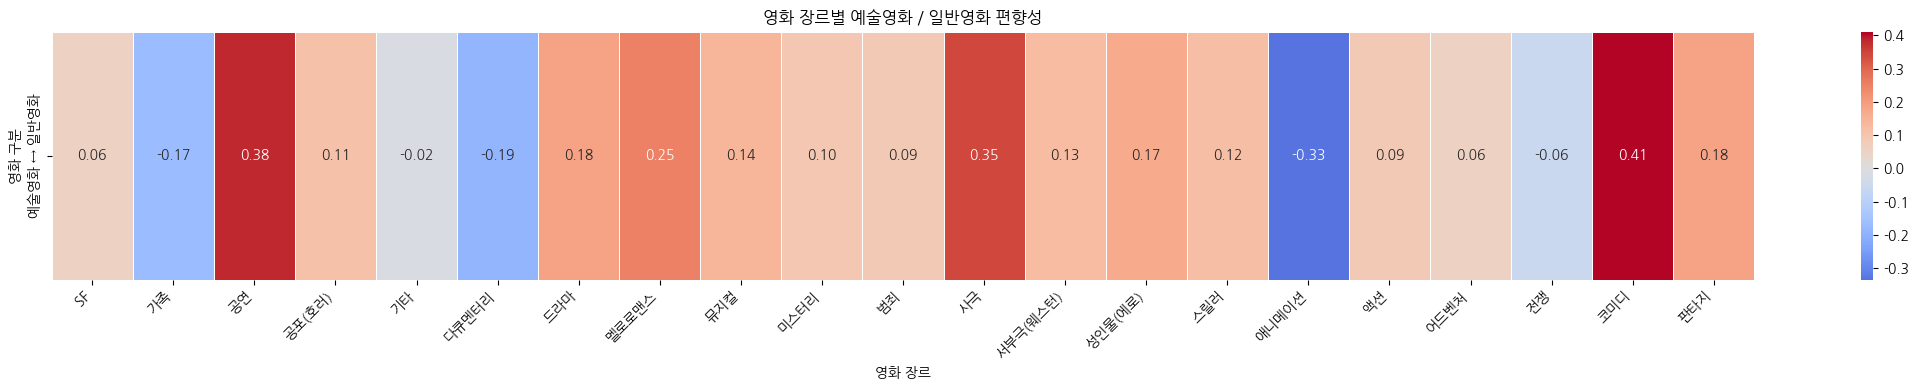

In [59]:
# ============================================================
# WEAT Heatmap
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns


# Heatmap용 데이터 생성
heatmap_df = pd.DataFrame(
    [
        [
            weat_scores[name]
            for name in genre_name
        ]
    ],
    index=['예술영화 ↔ 일반영화'],
    columns=genre_name
)


# Heatmap 그리기
plt.figure(figsize=(22, 4))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt='.2f',
    center=0,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title(
    '영화 장르별 예술영화 / 일반영화 편향성'
)

plt.xlabel('영화 장르')
plt.ylabel('영화 구분')

plt.xticks(
    rotation=45,
    ha='right'
)

plt.tight_layout()
plt.show()

In [57]:
# ============================================================
# WEAT 절댓값이 큰 장르 확인
# ============================================================

print("편향성이 큰 장르 TOP 10")
print()


top_genres = result_df.head(10)


for _, row in top_genres.iterrows():

    print(
        f"{row['장르']:15s}"
        f" WEAT = {row['WEAT Score']:.4f}"
    )

편향성이 큰 장르 TOP 10

코미디             WEAT = 0.4110
공연              WEAT = 0.3844
사극              WEAT = 0.3467
애니메이션           WEAT = -0.3340
멜로로맨스           WEAT = 0.2529
다큐멘터리           WEAT = -0.1894
판타지             WEAT = 0.1830
드라마             WEAT = 0.1818
가족              WEAT = -0.1737
성인물(에로)         WEAT = 0.1691


In [58]:
# ============================================================
# 최종 결과 요약
# ============================================================

print("\n")
print("=" * 70)
print("최종 분석 결과")
print("=" * 70)


print("\n[Target]")
print("예술영화 :", ', '.join(art_words))
print("일반영화 :", ', '.join(gen_words))


print("\n[Genre Attribute & WEAT]")


for name in genre_name:

    print(
        f"\n{name}"
    )

    print(
        "대표 단어 :",
        ', '.join(genre_words[name])
    )

    print(
        "WEAT Score :",
        f"{weat_scores[name]:.4f}"
    )



최종 분석 결과

[Target]
예술영화 : 그녀, 자신, 시작, 위해, 사랑, 사람, 영화, 친구
일반영화 : 자신, 그녀, 영화제, 위해, 사람, 시작, 영화, 친구

[Genre Attribute & WEAT]

SF
대표 단어 : 위해, 자신, 시작, 지구, 사람, 인간, 인류, 그녀
WEAT Score : 0.0557

가족
대표 단어 : 엄마, 영화제, 아빠, 자신, 가족, 위해, 친구, 아버지
WEAT Score : -0.1737

공연
대표 단어 : 사랑, 자신, 오페라, 그녀, 위해, 왕자, 토스카, 시작
WEAT Score : 0.3844

공포(호러)
대표 단어 : 시작, 위해, 사람, 자신, 친구, 그녀, 사건, 공포
WEAT Score : 0.1109

기타
대표 단어 : 영화제, 자신, 영화, 사람, 이야기, 그녀, 남자, 위해
WEAT Score : -0.0164

다큐멘터리
대표 단어 : 영화제, 영화, 사람, 다큐멘터리, 이야기, 대한, 자신, 감독
WEAT Score : -0.1894

드라마
대표 단어 : 자신, 영화제, 그녀, 사람, 사랑, 위해, 영화, 시작
WEAT Score : 0.1818

멜로로맨스
대표 단어 : 그녀, 사랑, 자신, 시작, 남자, 남편, 사람, 여자
WEAT Score : 0.2529

뮤지컬
대표 단어 : 사랑, 그녀, 뮤지컬, 음악, 영화, 자신, 영화제, 시작
WEAT Score : 0.1433

미스터리
대표 단어 : 사건, 그녀, 시작, 자신, 위해, 사람, 발견, 죽음
WEAT Score : 0.0957

범죄
대표 단어 : 사건, 위해, 자신, 시작, 경찰, 그녀, 살인, 사람
WEAT Score : 0.0885

사극
대표 단어 : 조선, 위해, 시작, 사랑, 자신, 그녀, 사람, 최고
WEAT Score : 0.3467

서부극(웨스턴)
대표 단어 : 서부, 위해, 마을, 보안관, 자신, 헨리, 아이, 카우보이
WEAT Score : 0.1270

성인물(에로)
대표 단어 : 

---
> # TF-IDF는 “중요한 단어”를 찾는 방법
> # Word2Vec 유사도는 “비슷한 의미의 단어인지”를 판단
---

| 기능          | 코드                              |
| ---------------- | ------------------------------- |
| 형태소 분석           | `read_token()`                  |
| 명사 추출            | `if word[1] in ["Noun"]`        |
| 예술/일반 영화 분석      | `art`, `gen`                    |
| 21개 장르 분석        | `genre`                         |
| Word Embedding   | `Word2Vec`                      |
| `most_similar()` | 7번 셀                            |
| TF-IDF 대표 단어 후보  | `get_tfidf_candidates()`        |
| TF-IDF 중복 문제 개선  | `select_representative_words()` |
| 의미적 중복 제거        | Word2Vec cosine similarity      |
| Target           | `art_words`, `gen_words`        |
| Attribute        | `genre_words`                   |
| WEAT             | `weat_effect_size()`            |
| 모든 장르 계산         | `weat_scores`                   |
| Heatmap          | `sns.heatmap()`                 |




### TF-IDF -> 대표 단어 후보 100개 -> Word2Vec으로 단어 간 의미 유사도 확인 -> 너무 비슷한 단어 제거 -> 최종 대표 단어 8개


### WEAT > 0 이면 해당 장르 Attribute가 일반영화보다 예술영화 Target에 상대적으로 더 연관